In [2]:
'''
In this notebook we will analyze the metric runs we've done already
'''

"\nIn this notebook we will analyze the metric runs we've done already\n"

In [1]:
#imports
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import importlib
import sys
import os
import ast

In [2]:
# --- User toggle ---
Cristina = False
Shar = not Cristina 

# --- System Configurations ---

if Cristina:
    print("[CONFIG] Using Cristina's local MacBook setup")
    sys.path.insert(0, "/Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub")
    os.environ["RUBIN_SIM_DATA_DIR"] = "/Users/andradenebula/rubin_sim_data"
    db_dir = "/Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub"
    base_dir = None
    
elif Shar:
    print("[CONFIG] Using Shar's Dirac server setup")
    sys.path.insert(0, "/lustre/lrspec/metrics")
    sys.path.insert(0, "/home/3155/metrics/Multi_Transient_Metrics_Hub")
    os.environ["RUBIN_SIM_DATA_DIR"] = "/lustre/lrspec/metrics/rubin_sim_data"
    db_dir = "/lustre/lrspec/metrics"
    base_dir = '/lustre/lrspec/metrics/results'

# Shared config
sys.path.append(os.path.abspath(".."))  # For shared_utils


[CONFIG] Using Shar's Dirac server setup


In [4]:
#this happens twice because idk why but it only works like that
#...you still have to run it twice if it gives warnings
# C: Make sure you save your metric file before running. 

metric_filename = "new_names_local_GRBafterglows_metric"
s_u = "shared_utils"

# --- Reload metric module ---
if metric_filename in sys.modules:
    del sys.modules[metric_filename]
metric = __import__(metric_filename)
importlib.reload(metric)

# --- Reload shared_utils module ---
if s_u in sys.modules:
    del sys.modules[s_u]
shared_utils = __import__(s_u)
importlib.reload(shared_utils)

print(f"[INFO] Loaded metric module: {metric_filename}")
print(f"[INFO] Loaded shared_utils module")




[INFO] Loaded metric module: new_names_local_GRBafterglows_metric
[INFO] Loaded shared_utils module


In [63]:
#metric configurations
testname=None  #use this to add text if you're testing something other than the below variables
testname_metric_only=None

#population variables
rate_density = 1e-7

# apply None for non-use case 
z_min, z_max = .00226, .3
d_min, d_max = None, None #3000, 4000

#other
use_extinction = False
ignore_triples = False #turn this to true to ignore triples

#cadence variables
cadences = ['four_roll_v4.3.1_10yrs', 'baseline_v4.3.1_10yrs', 'noroll_v3.6_10yrs']

# paths = metric.get_output_paths(case_label="GRBafterglows")  # <- can change to 'KNe' etc.
paths = shared_utils.build_filenames(testname=testname, testname_metric_only=testname_metric_only,
                        science_case="GRBafterglows", 
                        rate_density=rate_density, 
                        z_min=z_min, 
                        z_max=z_max,
                        d_min=d_min, 
                        d_max=d_max,
                        ignore_triples=ignore_triples,                   
                        use_extinction=use_extinction,
                        base_dir=base_dir)


templates_file, pop_file, df_file, storage_dir, sum_file = paths

to_load = df_file+"ObsRecords_"+cadences[0]+'.csv'

GRBafterglows_den_1e-07_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_False_None


In [64]:
df_obs = pd.read_csv(to_load)

In [65]:
df_obs

,sid,mjd_obs,mag_obs,snr_obs,filter,first_det_mjd,last_det_mjd,fade_time_days,sid_duplicate,file_indx,...,detected,theta_obs,distance_modulus,year,n_observations_detected,n_filters_detected,peak_abs_mag_g,alpha_fade_g,t_jetbreak_g,peak_apparent_mag_g_noebv
0,1,"[64347.14632091699, 64347.12356130418, 64291.2...","[138.6661886154917, 138.6661886154917, 138.666...","[9.649827164254777e-47, 9.709731200489797e-47,...","['y', 'y', 'z', 'y', 'z', 'y', 'i', 'r', 'u', ...",64472.410509,64473.436071,17.035453,1,37,...,False,0.689389,39.666189,10,3,2,-29.205962,-22.225688,-8.534172,10.460227
1,2,"[61728.131224077966, 62454.3016272885, 62454.2...","[139.09591833573495, 139.09591833573495, 139.0...","[1.0560766225356377e-45, 1.2421194674183064e-4...","['g', 'y', 'y', 'z', 'r', 'z', 'y', 'y', 'r', ...",NaN,NaN,NaN,2,881,...,False,1.348682,40.095918,3,0,0,-20.532770,-13.286735,-0.667998,19.563149
2,3,"[63420.19647675333, 61884.385486063686, 61884....","[138.13360805031004, 138.13360805031004, 138.1...","[4.378523210063135e-46, 1.400836811256726e-45,...","['i', 'r', 'g', 'r', 'i', 'r', 'g', 'r', 'z', ...",63727.357381,63740.327290,13.814022,3,632,...,False,1.095423,39.133608,8,4,2,-23.251382,-17.615422,-1.112883,15.882226
3,4,"[61461.32059103347, 61479.347512385575, 63769....","[136.4020609733597, 136.4020609733597, 136.402...","[3.71437236722748e-46, 8.597268517861768e-45, ...","['y', 'r', 'z', 'i', 'r', 'y', 'i', 'u', 'z', ...",NaN,NaN,NaN,4,964,...,False,0.147933,37.402061,6,0,0,-23.753114,-14.425601,-2.125216,13.648947
4,5,"[61490.332320421156, 61490.30894890274, 63301....","[138.72646969781388, 138.72646969781388, 138.7...","[8.770246615431425e-47, 1.298551946916981e-46,...","['y', 'y', 'r', 'i', 'g', 'z', 'r', 'i', 'r', ...",NaN,NaN,NaN,5,582,...,False,1.532504,39.726470,4,0,0,-22.094342,-13.968965,0.158555,17.632127
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5275,7778,"[64398.127180179705, 62290.96827501535, 64017....","[139.2718215539936, 139.2718215539936, 139.271...","[1.0112922492891078e-46, 3.0691807729001052e-4...","['z', 'i', 'i', 'r', 'i', 'r', 'r', 'i', 'i', ...",NaN,NaN,NaN,7778,636,...,False,0.316603,40.271822,1,0,0,-21.322856,-13.192972,3.745291,18.948966
5276,7780,"[61226.25138428813, 61226.22442187747, 63840.1...","[139.02987786475512, 139.02987786475512, 139.0...","[9.401496431271033e-47, 1.8991140796090058e-46...","['y', 'z', 'z', 'r', 'g', 'i', 'g', 'i', 'i', ...",NaN,NaN,NaN,7780,460,...,False,1.199027,40.029878,7,0,0,-26.202960,-22.116285,-8.241400,13.826917
5277,7782,"[63637.28867172272, 61071.28509728128, 63637.3...","[138.07144489696248, 138.07144489696248, 138.0...","[1.8799166805822987e-45, 2.187903278245106e-46...","['r', 'y', 'g', 'y', 'z', 'i', 'i', 'r', 'y', ...",NaN,NaN,NaN,7782,176,...,False,0.793118,39.071445,2,0,0,-21.725256,-14.562570,-1.286896,17.346189
5278,7783,"[63099.988739424065, 64161.30434122712, 62442....","[137.2864439504482, 137.2864439504482, 137.286...","[1.1329006528461492e-45, 1.6328037699592335e-4...","['r', 'r', 'i', 'r', 'u', 'r', 'r', 'i', 'z', ...",NaN,NaN,NaN,7783,227,...,False,0.350271,38.286444,1,0,0,-29.211008,-25.616681,-11.386271,9.075436


In [387]:
importlib.reload(metric)

<module 'new_names_local_GRBafterglows_metric' from '/home/3155/metrics/Multi_Transient_Metrics_Hub/GRBafterglows/new_names_local_GRBafterglows_metric.py'>

(40.0, 5.0)

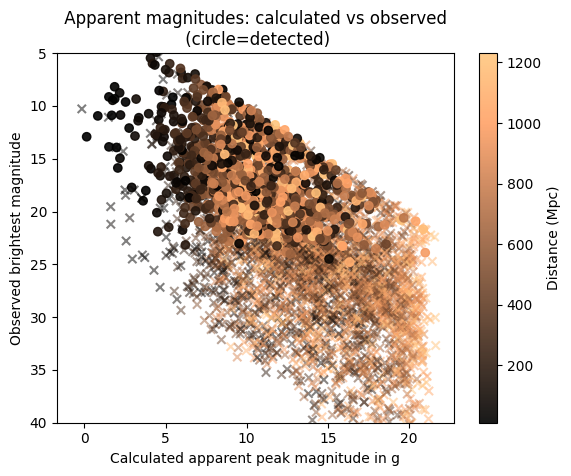

In [13]:
fig, ax = plt.subplots()
not_detected_df = df_obs[df_obs['detected']==False]
detected_df = df_obs[df_obs['detected']==True]
plt.scatter(not_detected_df['peak_apparent_mag_g_noebv'], not_detected_df['peak_mag_observed'], marker='x',c=not_detected_df['distance_Mpc'], alpha=.5, cmap='copper')
plt.scatter(detected_df['peak_apparent_mag_g_noebv'], detected_df['peak_mag_observed'], marker='o',c=detected_df['distance_Mpc'], alpha=.9, cmap='copper')
plt.title(" Apparent magnitudes: calculated vs observed \n (circle=detected)")
plt.xlabel("Calculated apparent peak magnitude in g")
plt.ylabel("Observed brightest magnitude")
ax.yaxis.set_inverted(True)
plt.colorbar(label="Distance (Mpc)")
plt.ylim(40,5)

In [8]:
def get_df(cadence_num, testname_metric_only = None, testname=None, use_extinction = False,ignore_triples = False):
    '''
    easy way to load the obs record dfs 
    use when rate_density = 1e-8
    cadence_num: 0,1,2, or 'all', depending on which cadence you want
    returns df, or if cadence_num='all', returns 3 df
    cadences go in order:['four_roll_v4.3.1_10yrs', 'baseline_v4.3.1_10yrs', 'noroll_v3.6_10yrs']
    '''
    
    rate_density = 1e-8

    # apply None for non-use case 
    z_min, z_max = .00226, .3
    d_min, d_max = None, None #3000, 4000

    #other
     #turn this to true to ignore triples

    #cadence variables
    cadences = ['four_roll_v4.3.1_10yrs', 'baseline_v4.3.1_10yrs', 'noroll_v3.6_10yrs']

    # paths = metric.get_output_paths(case_label="GRBafterglows")  # <- can change to 'KNe' etc.
    paths = shared_utils.build_filenames(testname=testname,testname_metric_only=testname_metric_only,
                            science_case="GRBafterglows", 
                            rate_density=rate_density, 
                            z_min=z_min, 
                            z_max=z_max,
                            d_min=d_min, 
                            d_max=d_max,
                            ignore_triples=ignore_triples,                   
                            use_extinction=use_extinction,
                            base_dir=base_dir)
    

    templates_file, pop_file, df_file, storage_dir, summary_file = paths
    
    # print(to_load)
    if cadence_num == 'all':
        to_load = df_file+"ObsRecords_"+cadences[0]+'.csv'
        to_load1 = df_file+"ObsRecords_"+cadences[1]+'.csv'
        to_load2 = df_file+"ObsRecords_"+cadences[2]+'.csv'
        return pd.read_csv(to_load), pd.read_csv(to_load1), pd.read_csv(to_load2)
    to_load = df_file+"ObsRecords_"+cadences[cadence_num]+'.csv'
    return pd.read_csv(to_load)

In [15]:
df_obs_4roll, df_obs_baseline,df_obs_noroll = get_df('all')


GRBafterglows_den_1e-08_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_False_None


In [64]:
# dfs = {'baseline_MAXGAP_100' :df_obs_baseline_MAXGAP_100,
#        '4roll_MAXGAP_100': df_obs_4roll_MAXGAP_100,
#        'baseline_MAXGAP_1' :df_obs_baseline,
#        '4roll_MAXGAP_1' :df_obs_4roll,
#        'baseline_MAXGAP_0.5' :df_obs_baseline_MAXGAP_p5,
#        '4roll_MAXGAP_0.5' :df_obs_4roll_MAXGAP_p5}


Text(0.5, 0, 'Number of observations of a single light curve')

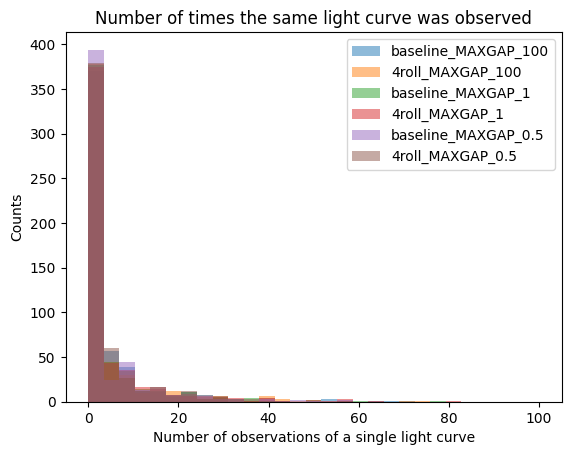

In [90]:
for key, value in dfs.items():
    plt.hist(value['n_observations_detected'],bins=np.linspace(0,100,30),label=key,alpha=.5)
# plt.ylim(0,100)
plt.legend()
plt.title("Number of times the same light curve was observed")
plt.ylabel("Counts")
plt.xlabel("Number of observations of a single light curve")

Text(0.5, 0, 'Number of detections in a single light curve')

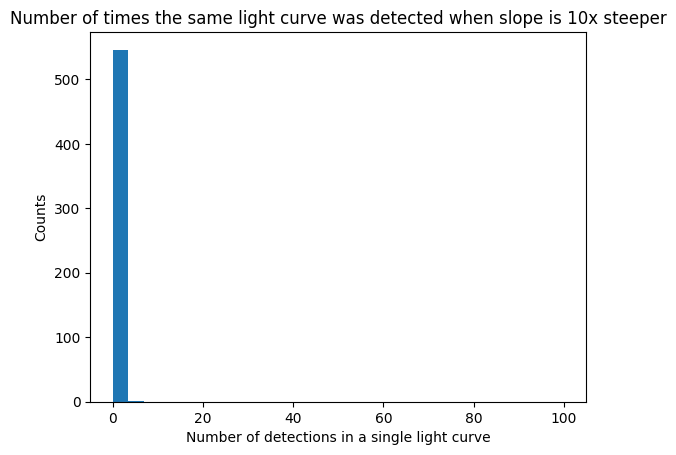

In [88]:
plt.hist(df_obs_baseline_MAXGAP_100_alpha10x['n_observations_detected'],bins=np.linspace(0,100,30))
plt.title("Number of times the same light curve was detected when slope is 10x steeper")
plt.ylabel("Counts")
plt.xlabel("Number of detections in a single light curve")

In [7]:
def get_df_big(cadence_num, testname_metric_only = None, testname=None,use_extinction = False,ignore_triples = False):
    '''
    easy way to load the obs record dfs 
    use when rate_density = 1e-7
    cadence_num: 0,1,2, or 'all', depending on which cadence you want
    returns df, or if cadence_num='all', returns 3 df
    cadences go in order:['four_roll_v4.3.1_10yrs', 'baseline_v4.3.1_10yrs', 'noroll_v3.6_10yrs']
    '''
    rate_density = 1e-7

    # apply None for non-use case 
    z_min, z_max = .00226, .3
    d_min, d_max = None, None #3000, 4000

    #other
    
     #turn this to true to ignore triples

    #cadence variables
    cadences = ['four_roll_v4.3.1_10yrs', 'baseline_v4.3.1_10yrs', 'noroll_v3.6_10yrs']

    # paths = metric.get_output_paths(case_label="GRBafterglows")  # <- can change to 'KNe' etc.
    paths = shared_utils.build_filenames(testname=testname,testname_metric_only=testname_metric_only,
                            science_case="GRBafterglows", 
                            rate_density=rate_density, 
                            z_min=z_min, 
                            z_max=z_max,
                            d_min=d_min, 
                            d_max=d_max,
                            ignore_triples=ignore_triples,                   
                            use_extinction=use_extinction,
                            base_dir=base_dir)
    

    templates_file, pop_file, df_file, storage_dir, summary_file = paths

    
    # print(to_load)
    if cadence_num == 'all':
        to_load = df_file+"ObsRecords_"+cadences[0]+'.csv'
        to_load1 = df_file+"ObsRecords_"+cadences[1]+'.csv'
        to_load2 = df_file+"ObsRecords_"+cadences[2]+'.csv'
        return pd.read_csv(to_load), pd.read_csv(to_load1), pd.read_csv(to_load2)
    to_load = df_file+"ObsRecords_"+cadences[cadence_num]+'.csv'
    return pd.read_csv(to_load)

In [127]:
importlib.reload(metric)

<module 'new_names_local_GRBafterglows_metric' from '/home/3155/metrics/Multi_Transient_Metrics_Hub/GRBafterglows/new_names_local_GRBafterglows_metric.py'>

In [231]:
def make_table(testname_metric_only, title=None):
    big_df_obs_4roll, big_df_obs_baseline, big_df_obs_noroll = get_df_big('all', testname_metric_only)
    if testname_metric_only=="None" or testname_metric_only==None:
        big_df_obs_4roll_MAXGAP_100, big_df_obs_baseline_MAXGAP_100, big_df_obs_noroll_MAXGAP_100 = get_df_big('all', 'MAXGAP_100')
        big_df_obs_4roll_MAXGAP_p5, big_df_obs_baseline_MAXGAP_p5, big_df_obs_noroll_MAXGAP_p5 = get_df_big('all', 'MAXGAP_p5')
    else:
        big_df_obs_4roll_MAXGAP_100, big_df_obs_baseline_MAXGAP_100, big_df_obs_noroll_MAXGAP_100 = get_df_big('all', testname_metric_only+'_MAXGAP_100')
        big_df_obs_4roll_MAXGAP_p5, big_df_obs_baseline_MAXGAP_p5, big_df_obs_noroll_MAXGAP_p5 = get_df_big('all', testname_metric_only+'_MAXGAP_p5')
    if title ==None:
        print(f"\nRequiring {testname_metric_only} \n")
    if title != None:
        print(f"\nRequiring {title} \n")
    print('               no roll, baseline, 4 roll')
    print('no maxgap      ',np.sum(big_df_obs_noroll_MAXGAP_100['detected']==True),np.sum(big_df_obs_baseline_MAXGAP_100['detected']==True),np.sum(big_df_obs_4roll_MAXGAP_100['detected']==True))
    print('maxgap 1 day   ',np.sum(big_df_obs_noroll['detected']==True),np.sum(big_df_obs_baseline['detected']==True),np.sum(big_df_obs_4roll['detected']==True))
    print('maxgap 0.5 day ',np.sum(big_df_obs_noroll_MAXGAP_p5['detected']==True),np.sum(big_df_obs_baseline_MAXGAP_p5['detected']==True),np.sum(big_df_obs_4roll_MAXGAP_p5['detected']==True))
   
    
    

In [259]:
make_table(None, title="two observations above snr 5 in any filter")

GRBafterglows_den_1e-07_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_False_None
GRBafterglows_den_1e-07_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_False_None
GRBafterglows_den_1e-07_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_False_None

Requiring two observations above snr 5 in any filter 

               no roll, baseline, 4 roll
no maxgap       1400 1415 1350
maxgap 1 day    1048 1070 1058
maxgap 0.5 day  971 1004 984


In [240]:
make_table_1detect('1detect_1filt_r', title="one observation above snr 5 in r")

GRBafterglows_den_1e-07_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_False_None

Requiring one observation above snr 5 in r 

no roll, baseline, 4 roll
1639 1627 1612


In [241]:
make_table_1detect('1detect_1filt_g', title="one observation above snr 5 in g")

GRBafterglows_den_1e-07_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_False_None

Requiring one observation above snr 5 in g 

no roll, baseline, 4 roll
1216 1212 1190


In [237]:
make_table('2detect_1filt_r', title="two observations above snr 5 in r")

GRBafterglows_den_1e-07_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_False_None
GRBafterglows_den_1e-07_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_False_None
GRBafterglows_den_1e-07_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_False_None

Requiring two observations above snr 5 in r 

               no roll, baseline, 4 roll
no maxgap       1034 1032 965
maxgap 1 day    565 569 579
maxgap 0.5 day  482 507 501


In [232]:
make_table('2detect_1filt_g', title="two observations above snr 5 in g")

GRBafterglows_den_1e-07_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_False_None
GRBafterglows_den_1e-07_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_False_None
GRBafterglows_den_1e-07_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_False_None

Requiring two observations above snr 5 in g 

               no roll, baseline, 4 roll
no maxgap       546 591 596
maxgap 1 day    238 288 275
maxgap 0.5 day  209 261 242


In [242]:
make_table_1detect('1detect', title="one observation above snr 5 in any filter")

GRBafterglows_den_1e-07_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_False_None

Requiring one observation above snr 5 in any filter 

no roll, baseline, 4 roll
2112 2101 2106


In [239]:
def make_table_1detect(testname_metric_only, title=None):
    big_df_obs_4roll, big_df_obs_baseline, big_df_obs_noroll = get_df_big('all', testname_metric_only)
    if title ==None:
        print(f"\nRequiring {testname_metric_only} \n")
    if title != None:
        print(f"\nRequiring {title} \n")
    print('no roll, baseline, 4 roll')
    # print(np.sum(big_df_obs_noroll['n_observations_detected']>=1),np.sum(big_df_obs_baseline['n_observations_detected']>=1),np.sum(big_df_obs_4roll['n_observations_detected']>=1))
    print(np.sum(big_df_obs_noroll['detected']==True),np.sum(big_df_obs_baseline['detected']==True),np.sum(big_df_obs_4roll['detected']==True))


In [283]:
canon_4roll_no_ebv, canon_baseline_no_ebv, canon_noroll_no_ebv, = get_df('all', testname_metric_only = None, testname=None, use_extinction=False)

GRBafterglows_den_1e-08_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_False_None


In [119]:
canon_4roll_w_ebv, canon_baseline_w_ebv, canon_noroll_w_ebv, = get_df('all', testname_metric_only = None, testname=None, use_extinction=True)

GRBafterglows_den_1e-08_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_True_None


In [293]:
big_4roll_no_ebv, big_baseline_no_ebv, big_noroll_no_ebv, = get_df_big('all', testname_metric_only = None, testname=None, use_extinction=False)

GRBafterglows_den_1e-07_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_False_None


In [294]:
big_4roll_w_ebv, big_baseline_w_ebv, big_noroll_w_ebv, = get_df_big('all', testname_metric_only = None, testname=None, use_extinction=True)

GRBafterglows_den_1e-07_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_True_None


In [297]:
len(big_4roll_w_ebv[big_4roll_w_ebv['detected']==True])

969

In [360]:
len(big_4roll_no_ebv[big_4roll_no_ebv['detected']==True])

1058

In [301]:
detected = big_4roll_no_ebv[big_4roll_no_ebv['detected']==True]

(array([220., 161., 165., 184., 134., 100.,  49.,  30.,  12.,   3.]),
 array([2.26901026e-02, 9.61904444e+00, 1.92153988e+01, 2.88117531e+01,
        3.84081074e+01, 4.80044618e+01, 5.76008161e+01, 6.71971705e+01,
        7.67935248e+01, 8.63898791e+01, 9.59862335e+01]),
 <BarContainer object of 10 artists>)

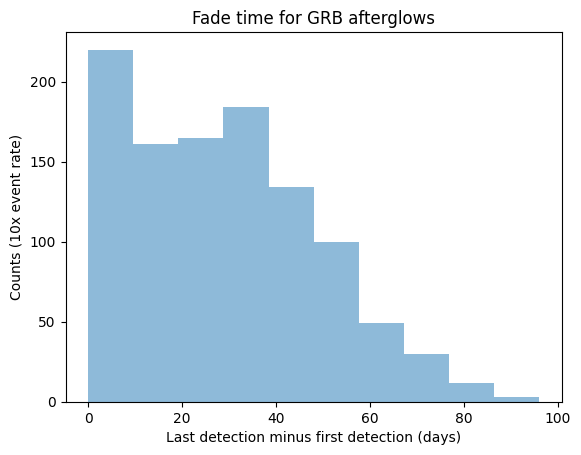

In [308]:
plt.title("Fade time for GRB afterglows")
plt.xlabel("Last detection minus first detection (days)")
plt.ylabel("Counts (10x event rate)")
plt.hist(detected['last_det_mjd']-detected['first_det_mjd'],alpha=.5)

In [330]:
#what i want is time until it's below 21st mag
#to do that i need to get into the stupid list
detected.iloc[0]['mag_obs']
mags = np.array(ast.literal_eval(detected.iloc[0]['mag_obs']))
mjd = np.array(ast.literal_eval(detected.iloc[0]['mjd_obs']))
snrs = np.array(ast.literal_eval(detected.iloc[0]['snr_obs']))

In [338]:
days_above_21 = []
for i,row in detected.iterrows():
    mags = np.array(ast.literal_eval(row['mag_obs']))
    mjd = np.array(ast.literal_eval(row['mjd_obs']))
    if np.sum(mags<21)>0:
        mjd_above_21 = mjd[mags<21]
        days_above_21.append(np.max(mjd_above_21)-np.min(mjd_above_21))
    else:
        days_above_21.append(0)
    

(array([143.,  77.,  74.,  87.,  71.,  94., 100.,  84.,  75.,  59.,  51.,
         49.,  29.,  20.,  18.,  12.,   4.,   8.,   1.,   2.]),
 array([2.26901026e-02, 4.82086727e+00, 9.61904444e+00, 1.44172216e+01,
        1.92153988e+01, 2.40135759e+01, 2.88117531e+01, 3.36099303e+01,
        3.84081074e+01, 4.32062846e+01, 4.80044618e+01, 5.28026389e+01,
        5.76008161e+01, 6.23989933e+01, 6.71971705e+01, 7.19953476e+01,
        7.67935248e+01, 8.15917020e+01, 8.63898791e+01, 9.11880563e+01,
        9.59862335e+01]),
 <BarContainer object of 20 artists>)

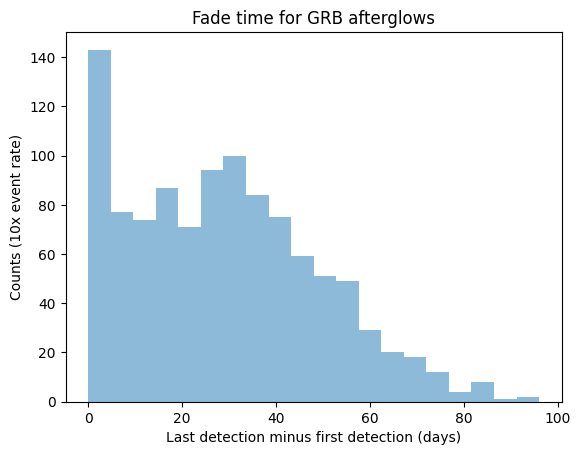

In [343]:
plt.title("Fade time for GRB afterglows")
plt.xlabel("Last detection minus first detection (days)")
plt.ylabel("Counts (10x event rate)")
plt.hist(detected['last_det_mjd']-detected['first_det_mjd'],alpha=.5, bins=20)

(array([429.,  77.,  80.,  89.,  70.,  57.,  63.,  46.,  38.,  27.,  23.,
         22.,  14.,   9.,   6.,   1.,   2.,   1.,   0.,   4.]),
 array([ 0.        ,  4.29089221,  8.58178441, 12.87267662, 17.16356882,
        21.45446103, 25.74535324, 30.03624544, 34.32713765, 38.61802985,
        42.90892206, 47.19981427, 51.49070647, 55.78159868, 60.07249088,
        64.36338309, 68.6542753 , 72.9451675 , 77.23605971, 81.52695191,
        85.81784412]),
 <BarContainer object of 20 artists>)

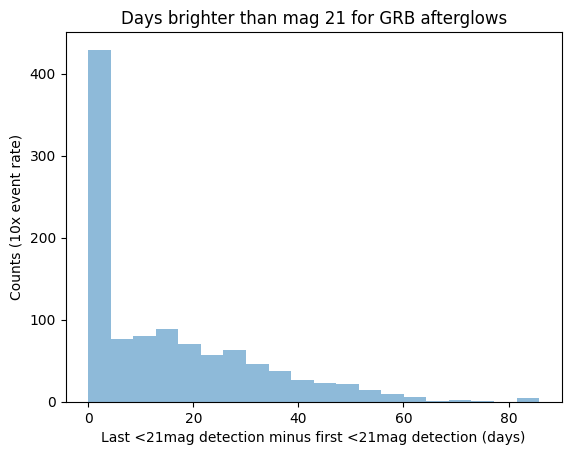

In [344]:

plt.title("Days brighter than mag 21 for GRB afterglows")
plt.xlabel("Last <21mag detection minus first <21mag detection (days)")
plt.ylabel("Counts (10x event rate)")
plt.hist(days_above_21,alpha=.5,bins=20)

In [55]:
def plot_observed_light_curve(row, log=True, ylim=True):
    '''
    takes a row from an obs dataframe, for instance: detected_df.iloc[4]
    returns nothing
    plots the observed light curve with each filter
    as a random color
    and events with snr>5 are bigger (open circles)
    nondetections are small dots
    '''
    unique_filters = np.unique(ast.literal_eval(row['filter']))
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_filters)))
    filter_to_color = dict(zip(unique_filters, colors))
    

    mjds = np.array(ast.literal_eval(row['mjd_obs']))
    snrs = np.array(ast.literal_eval(row['snr_obs']))
    mags = np.array(ast.literal_eval(row['mag_obs'].replace('nan', 'None')))
    
    mjds = mjds[mags!=None]
    snrs= snrs[mags!=None]
    color_array = np.array([filter_to_color[f] for f in ast.literal_eval(row['filter'])])[mags!=None]

    mags = mags[mags!=None]
    print(mags)
    print(snrs)
    print(color_array)


    snr_mask = snrs > 5  
    print(snr_mask)
    for m in snr_mask:
        print(type(m))
    snr_to_marker = {False: '.', True: 'o'}

    # plt.figure(figsize=(10, 6))
    log=log

    # Loop over each filter and SNR condition
    for snr_cond in [True, False]:
        print(snr_cond)
        print(type(snr_cond))
        if log:
            plt.scatter(
                np.log10(np.array(mjds)[snr_mask==snr_cond]),
                np.array(mags)[snr_mask==snr_cond],
                c=color_array[snr_mask==snr_cond],
                marker=snr_to_marker[snr_cond]
            )
        else:
            plt.scatter(
                np.array(mjds)[snr_mask==snr_cond],
                np.array(mags)[snr_mask==snr_cond],
                c=color_array[snr_mask==snr_cond],
                marker=snr_to_marker[snr_cond]
            )

    # if log:
        # plt.xlim(np.log10(np.array(row['peak_mjd_observed']) - 10), np.log10(np.array(row['peak_mjd_observed']) + 100))
    # else:
        # plt.xlim(np.array(row['peak_mjd_observed']) - 10, np.array(row['peak_mjd_observed']) + 100)
    plt.gca().invert_yaxis()
    # if log:
        # plt.xlabel("log MJD")
    # else:
        # plt.xlabel("MJD")
    plt.ylabel("Apparent mag")
    plt.title("Light Curve as Observed")
    plt.legend(["Large means detected",
                "Each color is a filter"])
    plt.tight_layout()
    # if ylim==True:
        # plt.ylim(40,16)
    # plt.xscale("log")
    plt.show()

In [100]:
detected = df_one[df_one['detected']==True]

In [70]:
import ast

In [96]:
get_df?

Signature:
get_df(
    cadence_num,
    testname_metric_only=None,
    testname=None,
    use_extinction=False,
    ignore_triples=False,
)
Docstring:
easy way to load the obs record dfs 
use when rate_density = 1e-8
cadence_num: 0,1,2, or 'all', depending on which cadence you want
returns df, or if cadence_num='all', returns 3 df
cadences go in order:['four_roll_v4.3.1_10yrs', 'baseline_v4.3.1_10yrs', 'noroll_v3.6_10yrs']
File:      /tmp/ipykernel_53566/1108569791.py
Type:      function

In [105]:
df_one = pd.read_csv('/lustre/lrspec/metrics/results/GRBafterglows/GRBafterglows_den_1e-09_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_False_40_None_obs_recordObsRecords_baseline_v4.3.1_10yrs.csv')

(array([31.,  5.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  9.]),
 array([ -1.73088668,  12.29970748,  26.33030164,  40.36089579,
         54.39148995,  68.42208411,  82.45267827,  96.48327243,
        110.51386659, 124.54446075, 138.5750549 ]),
 <BarContainer object of 10 artists>)

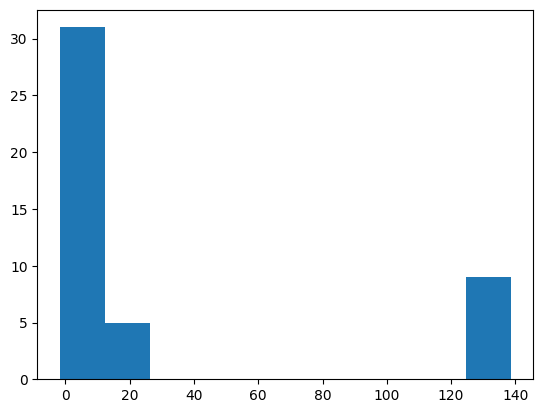

In [112]:
plt.hist(df_one['peak_mag_observed'])

(61200.0, 61600.0)

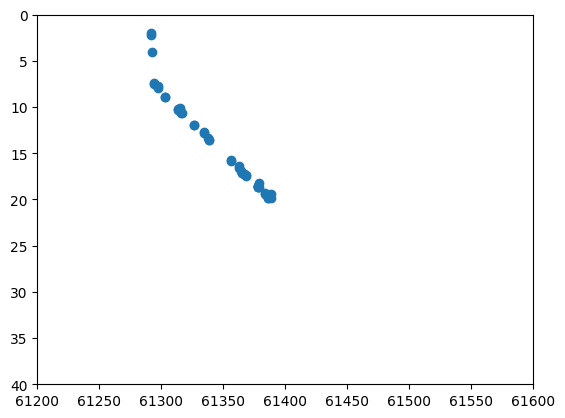

In [117]:
detected = df_one[df_one['detected']==True]
row = detected.iloc[0]
mjds = np.array(ast.literal_eval(row['mjd_obs']))
snrs = np.array(ast.literal_eval(row['snr_obs']))
mags = np.array(ast.literal_eval(row['mag_obs']))
plt.scatter(mjds, mags)
plt.ylim(40,0)
plt.xlim(61200,61600)

In [118]:
detected

,sid,mjd_obs,mag_obs,snr_obs,filter,first_det_mjd,last_det_mjd,fade_time_days,sid_duplicate,file_indx,...,peak_mjd_observed,peak_mag_observed,ebv,peak_time,detected,theta_obs,distance_modulus,year,n_observations_detected,n_filters_detected
1,2,"[61419.11919336897, 61419.14345948261, 63614.1...","[138.22896686081498, 138.22896686081498, 138.2...","[1.1309025464307025e-45, 5.064360306906325e-46...","['i', 'z', 'z', 'i', 'y', 'y', 'g', 'r', 'r', ...",61291.328380,61388.243616,98.437400,2,0,...,61291.328380,1.957206,0.0,309.306216,True,1.348682,39.228967,1,53,6
3,4,"[63284.36637342841, 64098.130083093005, 61919....","[138.47732660010973, 138.47732660010973, 138.4...","[3.4599005561711808e-46, 1.2071368136651087e-4...","['z', 'r', 'r', 'i', 'g', 'g', 'r', 'r', 'z', ...",61135.288410,61225.053745,91.620397,4,0,...,61135.288410,3.190863,0.0,152.933349,True,0.147933,39.477327,1,51,6
6,10,"[61291.97591873902, 61291.97906834007, 61291.9...","[136.17588218986015, 136.17588218986015, 136.1...","[1.3020855782239664e-45, 1.5300272064122896e-4...","['r', 'r', 'r', 'z', 'y', 'z', 'r', 'r', 'r', ...",61605.074829,61655.981760,51.646832,10,0,...,61605.074829,-1.176012,0.0,623.834928,True,0.582448,37.175882,2,9,5
7,11,"[62424.151983862095, 62424.127705563995, 64600...","[137.53578789310046, 137.53578789310046, 137.5...","[7.109582277896863e-46, 9.752765793077052e-46,...","['z', 'i', 'i', 'z', 'y', 'u', 'u', 'i', 'y', ...",64399.033927,64450.410489,91.296937,11,0,...,64399.033927,10.953189,0.0,3378.613552,True,1.455759,38.535788,10,13,5
9,13,"[62238.389796885116, 62238.36564013812, 62132....","[136.35679497247781, 136.35679497247781, 136.3...","[5.422081491064193e-45, 1.1252233569878987e-44...","['r', 'g', 'i', 'i', 'i', 'i', 'i', 'r', 'i', ...",62248.315570,62334.132375,86.210719,13,0,...,62248.315570,-1.730887,0.0,1267.421656,True,1.292391,37.356795,4,26,6
10,14,"[64291.34004104695, 62188.1767258886, 64291.34...","[133.55032270362517, 133.55032270362517, 133.5...","[5.578866655854283e-44, 1.18621472854352e-44, ...","['i', 'y', 'z', 'z', 'r', 'i', 'y', 'z', 'z', ...",63163.219202,63234.293196,95.360736,14,0,...,63163.219202,5.469107,0.0,2158.432459,True,0.696513,34.550323,6,53,5
11,15,"[64355.183330912085, 64355.159137002396, 63382...","[136.74536010694362, 136.74536010694362, 136.7...","[3.320696256290132e-45, 3.918860528943511e-45,...","['i', 'r', 'r', 'z', 'r', 'u', 'i', 'g', 'r', ...",61066.367920,61158.145250,93.388317,15,0,...,61066.367920,0.638112,0.0,84.256933,True,0.356946,37.745360,1,60,6
12,16,"[62705.41894580971, 64606.27945653378, 61682.2...","[136.83504374611638, 136.83504374611638, 136.8...","[1.5269951500784112e-45, 2.050374704484418e-45...","['i', 'i', 'z', 'r', 'i', 'i', 'i', 'z', 'i', ...",64521.329849,64578.225596,97.025909,16,0,...,64521.329849,10.484650,0.0,3500.699688,True,0.871140,37.835044,10,28,6
14,19,"[63048.39179484205, 63048.367645956874, 63183....","[138.9304519336025, 138.9304519336025, 138.930...","[5.059558002568166e-46, 7.696147710088355e-46,...","['r', 'g', 'z', 'i', 'i', 'i', 'i', 'g', 'i', ...",61292.193822,61332.149310,48.602081,19,0,...,61292.218073,8.775348,0.0,303.047230,True,0.992216,39.930452,1,8,3
17,23,"[62029.3331018243, 62068.198593152294, 61029.0...","[135.65375224646698, 135.65375224646698, 135.6...","[1.104787806582623e-44, 1.099805419922685e-44,...","['r', 'i', 'z', 'i', 'u', 'i', 'r', 'i', 'z', ...",63093.410502,63168.238533,99.359414,23,0,...,63093.410502,7.444844,0.0,2088.379119,True,1.402911,36.653752,6,77,6


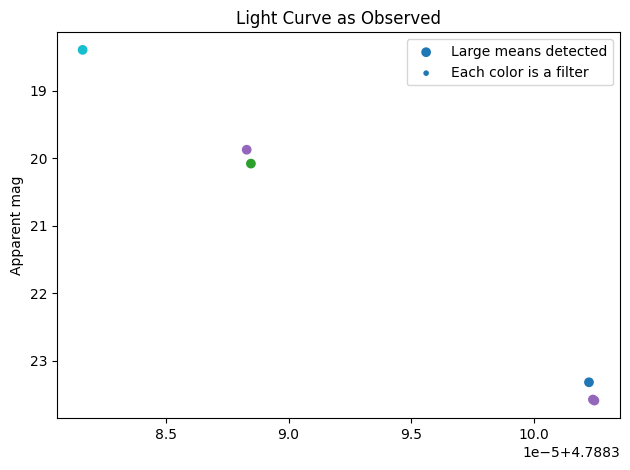

In [110]:
plot_observed_light_curve(detected.iloc[0],log="fake",ylim=False)

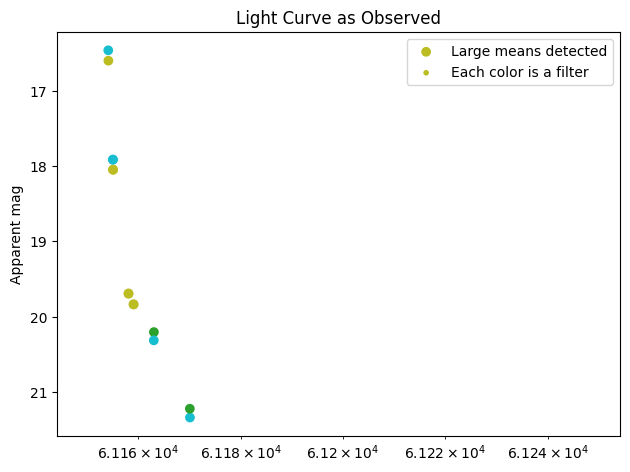

In [85]:
num_plotted=0
row = detected.iloc[0]
plot_observed_light_curve(row,log="fake",ylim=False)
    # if num_plotted>1:
    #     break
    # num_plotted+=1

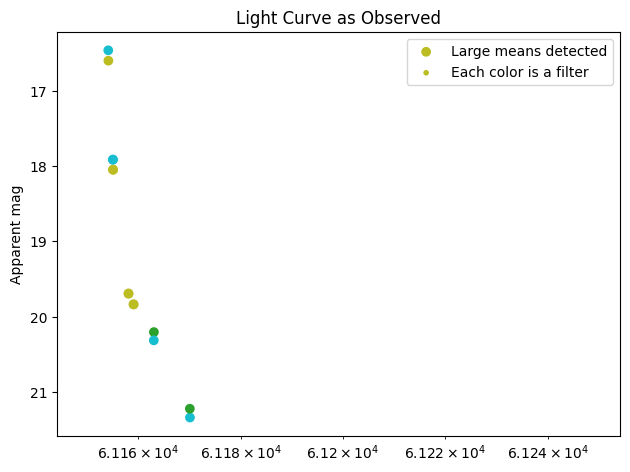

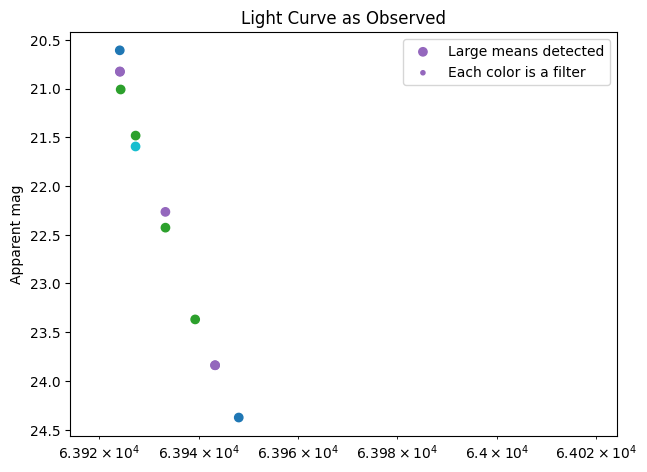

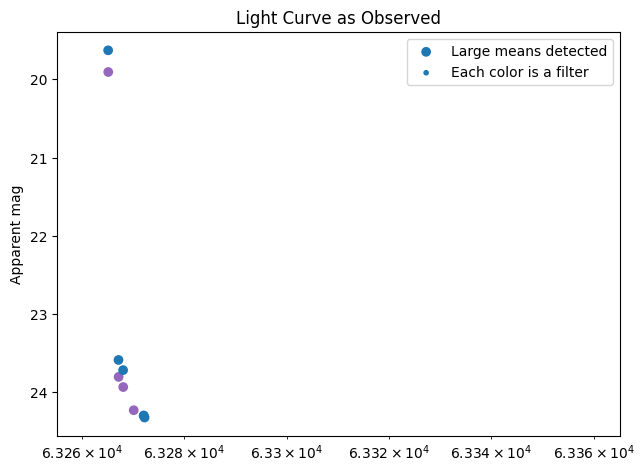

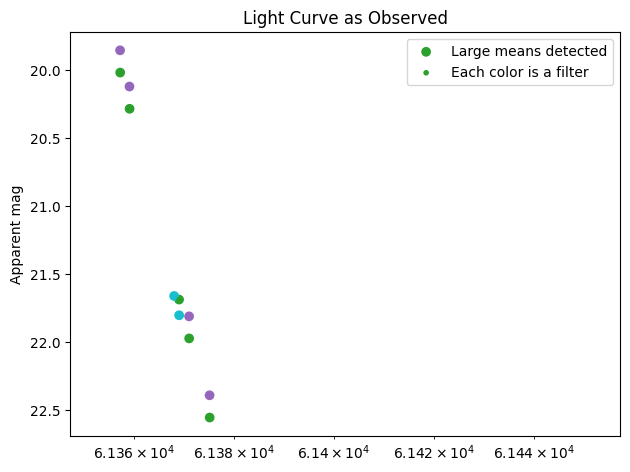

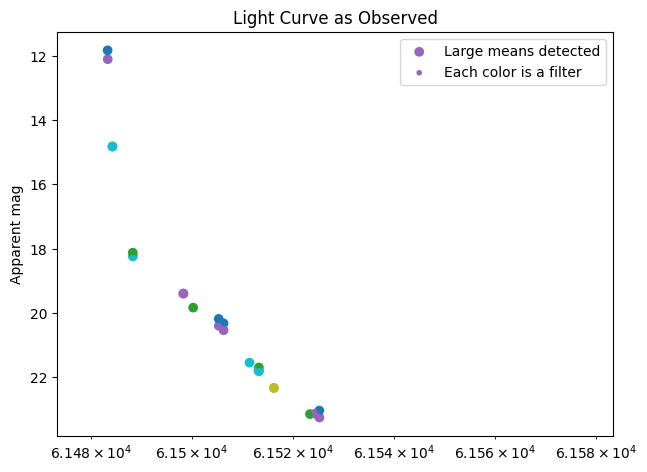

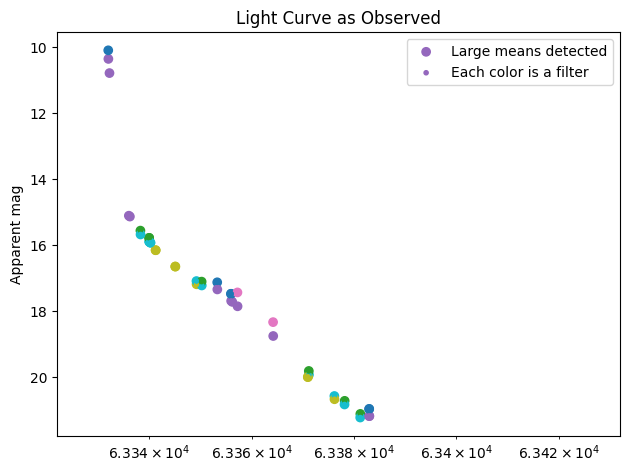

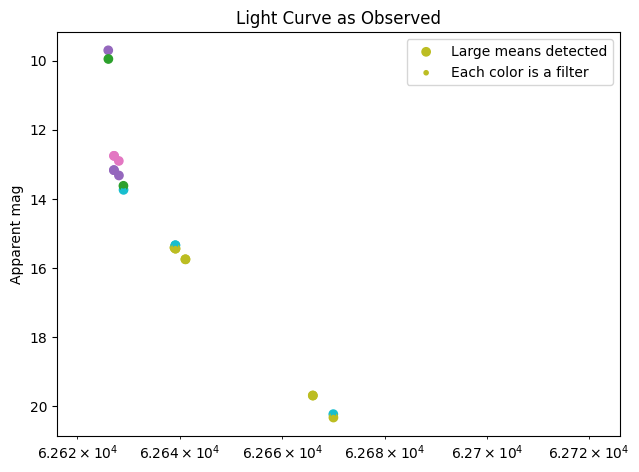

In [82]:
num_plotted=0
for i, row in detected.iterrows():
    plot_observed_light_curve(row,log=True,ylim=False)
    if num_plotted>5:
        break
    num_plotted+=1

In [9]:
big_4roll_w_ebv, big_baseline_w_ebv, big_noroll_w_ebv, = get_df_big('all', testname_metric_only = None, testname=None, use_extinction=True)

GRBafterglows_den_1e-07_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_True_None


In [12]:
big_4roll_no_ebv, big_baseline_no_ebv, big_noroll_no_ebv, = get_df_big('all', testname_metric_only = None, testname=None, use_extinction=False)

GRBafterglows_den_1e-07_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_False_None


In [11]:
np.sum(big_4roll_w_ebv['detected']==True),np.sum(big_baseline_w_ebv['detected']==True)

(np.int64(969), np.int64(979))

In [46]:
(979-969)/979

0.010214504596527068

In [13]:
np.sum(big_4roll_no_ebv['detected']==True),np.sum(big_baseline_no_ebv['detected']==True)

(np.int64(1058), np.int64(1070))

In [17]:
np.average(big_4roll_w_ebv['n_observations_detected']),np.average(big_baseline_w_ebv['n_observations_detected'])

(np.float64(3.921253965292032), np.float64(3.943583037549038))

In [18]:
np.average(big_4roll_w_ebv['n_filters_detected']),np.average(big_baseline_w_ebv['n_filters_detected'])

(np.float64(1.2300802388505319), np.float64(1.2570521203063703))

In [48]:
#number of observations in detected obsercations
detected_big_4roll_w_ebv = big_4roll_w_ebv[big_4roll_w_ebv['detected']==True]
detected_big_baseline_w_ebv = big_baseline_w_ebv[big_baseline_w_ebv['detected']==True]


In [49]:
np.average(detected_big_4roll_w_ebv['n_observations_detected']),np.average(detected_big_baseline_w_ebv['n_observations_detected'])

(np.float64(18.13003095975232), np.float64(17.84065372829418))

In [50]:
big_4roll_w_ebv

,sid,mjd_obs,mag_obs,snr_obs,filter,first_det_mjd,last_det_mjd,fade_time_days,sid_duplicate,file_indx,...,detected,theta_obs,distance_modulus,year,n_observations_detected,n_filters_detected,peak_abs_mag_g,alpha_fade_g,t_jetbreak_g,peak_apparent_mag_g_noebv
0,1,"[64347.14632091699, 64347.12356130418, 64291.2...","[27.797270769387573, 27.793542906539518, 137.2...","[0.02148259165175206, 0.02169029660605208, 6.3...","['y', 'y', 'z', 'y', 'z', 'y', 'i', 'r', 'u', ...",64327.124736,64327.128764,8.291737,1,738,...,False,0.689389,38.260862,10,2,1,-19.752437,-15.471453,0.669341,18.508425
1,2,"[61728.131224077966, 62454.3016272885, 62454.2...","[138.60813876895963, 138.4997750855547, 138.49...","[1.6550352795007434e-45, 2.1509022233746693e-4...","['g', 'y', 'y', 'z', 'r', 'z', 'y', 'y', 'r', ...",NaN,NaN,NaN,2,252,...,False,1.348682,39.439547,8,0,0,-27.520433,-18.996740,-2.366441,11.919115
2,3,"[63420.19647675333, 61884.385486063686, 61884....","[139.80788955141355, 139.9577098577801, 140.17...","[9.367313512020692e-47, 2.6106390063376487e-46...","['i', 'r', 'g', 'r', 'i', 'r', 'g', 'r', 'z', ...",63046.195834,63047.216099,1.078620,3,653,...,True,1.095423,40.332861,6,4,2,-23.803428,-15.381668,-0.983948,16.529433
3,4,"[61461.32059103347, 61479.347512385575, 63769....","[138.61004030180231, 138.6529251197292, 138.61...","[4.860642818767038e-47, 1.081470886717104e-45,...","['y', 'r', 'z', 'i', 'r', 'y', 'i', 'u', 'z', ...",NaN,NaN,NaN,4,526,...,False,0.147933,39.569801,5,0,0,-18.800951,-8.201270,4.391512,20.768849
4,5,"[61490.332320421156, 61490.30894890274, 63301....","[139.4968355187295, 139.4968355187295, 139.648...","[4.313854345470791e-47, 6.387236533543844e-47,...","['y', 'y', 'r', 'i', 'g', 'z', 'r', 'i', 'r', ...",NaN,NaN,NaN,5,366,...,False,1.532504,40.354635,10,0,0,-20.563710,-15.863329,1.104865,19.790925
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5354,7892,"[63264.187567218476, 63650.1241760822, 62094.3...","[139.31438224135468, 139.31438224135468, 139.3...","[1.6741750678294908e-46, 2.256110645692153e-46...","['r', 'r', 'r', 'r', 'i', 'i', 'i', 'g', 'r', ...",NaN,NaN,NaN,7892,554,...,False,0.162010,40.199940,5,0,0,-21.583447,-14.944249,-2.436546,18.616493
5355,7894,"[64019.16500403325, 64363.243184675666, 64019....","[135.9591815264451, 136.05130557243615, 135.95...","[3.6996476466134436e-45, 4.3092375749807666e-4...","['z', 'u', 'y', 'r', 'z', 'r', 'y', 'i', 'y', ...",NaN,NaN,NaN,7894,132,...,False,0.602321,36.912929,6,0,0,-21.025497,-14.305094,-0.098620,15.887432
5356,7896,"[61080.200939067356, 61055.1175234967, 62194.1...","[139.3379285020505, 139.54506172149252, 138.89...","[5.0396490401165304e-46, 1.8752470185286344e-4...","['g', 'u', 'y', 'y', 'y', 'y', 'r', 'r', 'u', ...",NaN,NaN,NaN,7896,512,...,False,0.917470,39.646528,8,0,0,-21.592560,-11.765264,1.067851,18.053968
5357,7897,"[63315.0802777019, 63315.05707183516, 61781.23...","[133.1374865878937, 133.1374865878937, 133.177...","[1.288053706644146e-44, 1.5697710521791085e-44...","['y', 'y', 'i', 'z', 'r', 'y', 'u', 'z', 'z', ...",63156.343816,63197.168967,99.936693,7897,686,...,True,0.116306,34.066556,6,17,4,-30.143996,-25.434491,-13.011807,3.922560


In [23]:
import healpy as hp

In [30]:
fourroll_no_ebv, baseline_no_ebv, noroll_no_ebv, = get_df('all', testname_metric_only = None, testname=None, use_extinction=False)

GRBafterglows_den_1e-08_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_False_None


Text(0, 0.5, 'counts')

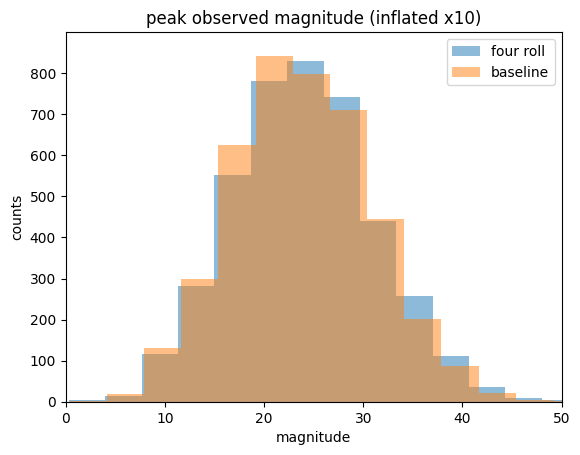

In [47]:
plt.hist(big_4roll_w_ebv['peak_mag_observed'], alpha=.5,label='four roll',bins=40)
plt.hist(big_baseline_w_ebv['peak_mag_observed'], alpha=.5,label='baseline',bins=40)
plt.xlim(0,50)
plt.legend()
plt.title("peak observed magnitude (inflated x10)")
plt.xlabel("magnitude")
plt.ylabel("counts")

In [53]:
def plot_map(df, title=None):
        '''
        takes obs_record dataframe, plots map of detection efficiency
        
        '''
        nside = 64
        npix = hp.nside2npix(nside)
        injected_map = np.zeros(npix)
        detected_map = np.zeros(npix)

        ra_rad = df['ra']
        dec_rad = df['dec']
        theta = 0.5 * np.pi - dec_rad
        phi = ra_rad
        pix_inds = hp.ang2pix(nside, theta, phi)

        for i, pix in enumerate(pix_inds):
            injected_map[pix] += 1
            #if detected_flags[i] :
            if df.iloc[i]['detected'] == 1:
                if np.random.rand() < 0.001:
                    print(f"[DEBUG] Detected RA, Dec: {np.degrees(ra_rad[i]):.2f}, {np.degrees(dec_rad[i]):.2f}")
                detected_map[pix] += 1

        eff_map = np.zeros(npix)
        mask = injected_map > 0
        eff_map[mask] = detected_map[mask] / injected_map[mask]
        eff_map[~mask] = hp.UNSEEN

        hp.mollview(eff_map, title=f"{title} Efficiency", unit='Efficiency', cmap='viridis')
        hp.graticule()
        plt.show

In [196]:
df_md = pd.read_csv('/lustre/lrspec/metrics/results/MDwarfFlares/MDwarfFlares_den_1e-08_d_100-1000_Mpc_z_0.00226-0.3_Mpc_ext_True_None_None_obs_recordObsRecords_four_roll_v4.3.1_10yrs.csv')

In [197]:
df_md

,sid,mjd_obs,mag_obs,snr_obs,filter,first_det_mjd,last_det_mjd,sid.1,file_indx,ra,...,peak_mjd_observed,peak_mag_observed,ebv,peak_time,detected,theta_obs,distance_modulus,year,n_observations_detected,n_filters_detected
0,1,"[64347.14632091699, 64347.12356130418, 64291.2...","[134.69753722810077, 134.69753722810077, 134.7...","[3.732330465824306e-45, 3.7554999646826894e-45...","['y', 'y', 'z', 'y', 'z', 'y', 'i', 'r', 'u', ...",NaN,NaN,1,389,0.613592,...,64347.146321,134.697537,0.021159,2914.853738,False,0.689389,35.669868,8,0,0
1,2,"[61728.131224077966, 62454.3016272885, 62454.2...","[136.41678482994143, 136.3084211465365, 136.30...","[1.245514624982767e-44, 1.6186846342811474e-45...","['g', 'y', 'y', 'z', 'r', 'z', 'y', 'y', 'r', ...",NaN,NaN,2,863,1.116738,...,62454.301627,136.308421,0.046056,365.597904,False,1.348682,37.248193,2,0,0
2,3,"[63420.19647675333, 61884.385486063686, 61884....","[136.11112153219045, 136.26094183855702, 136.4...","[2.820475057447649e-45, 7.86056983352384e-45, ...","['i', 'r', 'g', 'r', 'i', 'r', 'g', 'r', 'z', ...",NaN,NaN,3,214,4.798292,...,63345.296281,135.938576,0.231308,747.254787,False,1.095423,36.636093,3,0,0
3,4,"[61461.32059103347, 61479.347512385575, 63769....","[137.75809388825238, 137.80097870617925, 137.7...","[1.0653008506644913e-46, 2.370245867769513e-45...","['y', 'r', 'z', 'i', 'r', 'y', 'i', 'u', 'z', ...",NaN,NaN,4,780,4.000622,...,61461.320591,137.758094,0.030771,2715.884933,False,0.147933,38.717854,8,0,0
4,5,"[61490.332320421156, 61490.30894890274, 63301....","[138.5765407629362, 138.5765407629362, 138.728...","[1.0068931345603883e-46, 1.4908395368496649e-4...","['y', 'y', 'r', 'i', 'g', 'z', 'r', 'i', 'r', ...",NaN,NaN,5,562,3.447765,...,61490.332320,138.576541,0.108740,85.484485,False,1.532504,39.434340,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
290,426,"[61428.36550039518, 61428.36862659309, 61428.3...","[138.15868157884137, 138.15868157884137, 138.1...","[1.0562636974738338e-46, 1.0828315720168325e-4...","['i', 'i', 'i', 'i', 'z', 'y', 'r', 'y', 'z', ...",NaN,NaN,426,373,4.725930,...,64467.252194,138.014399,0.193420,2025.110834,False,0.374718,38.761462,6,0,0
291,427,"[61290.0006634278, 61290.02785566598, 62770.18...","[138.87624736437664, 138.68146318476357, 138.6...","[3.22738997076053e-46, 8.315130345045224e-46, ...","['u', 'r', 'r', 'y', 'u', 'y', 'i', 'r', 'y', ...",NaN,NaN,427,626,5.608234,...,61191.341160,138.549419,0.094746,1171.932461,False,1.334248,39.425519,4,0,0
292,429,"[63150.182420275305, 63150.208483483475, 64048...","[138.65689578114245, 138.754934987574, 138.656...","[3.55763911929751e-46, 8.277358245460005e-47, ...","['r', 'u', 'r', 'r', 'y', 'u', 'z', 'i', 'r', ...",NaN,NaN,429,747,5.375069,...,63526.022629,138.590435,0.047688,1383.242267,False,1.258151,39.528073,4,0,0
293,431,"[61781.343406243854, 61781.35284230985, 61155....","[135.66176115058926, 135.66176115058926, 135.7...","[2.1611996028524043e-45, 2.0576629636633028e-4...","['y', 'y', 'z', 'r', 'y', 'y', 'y', 'r', 'y', ...",NaN,NaN,431,894,2.417554,...,61781.343406,135.661761,0.169024,607.294671,False,1.212825,36.440727,2,0,0


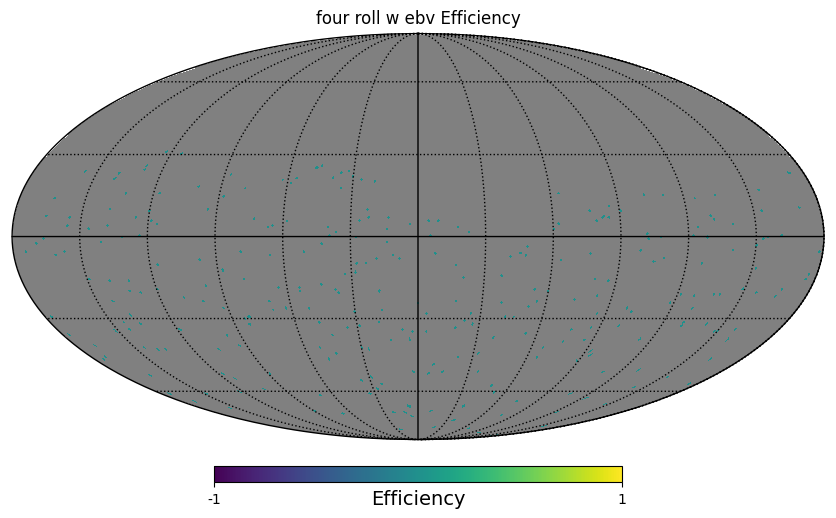

In [198]:
plot_map(df_md, title='four roll w ebv')

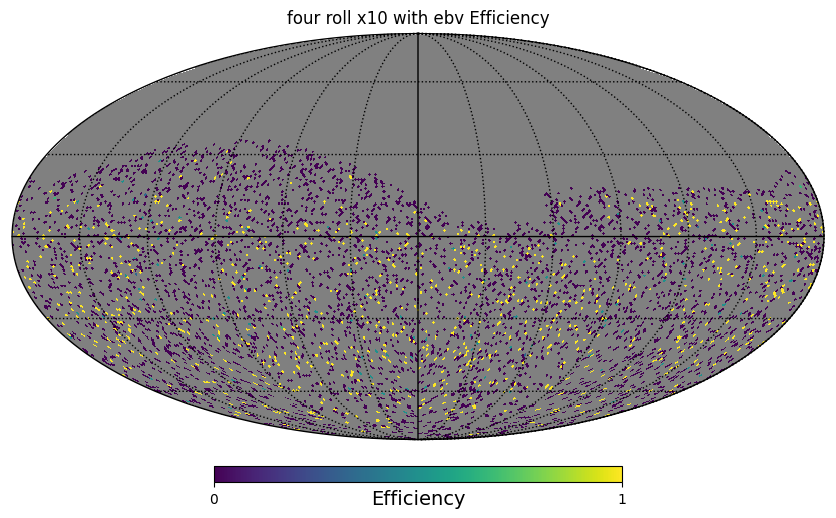

In [195]:
plot_map(big_4roll_w_ebv, title='four roll x10 with ebv')

[DEBUG] Detected RA, Dec: 134.30, -13.25


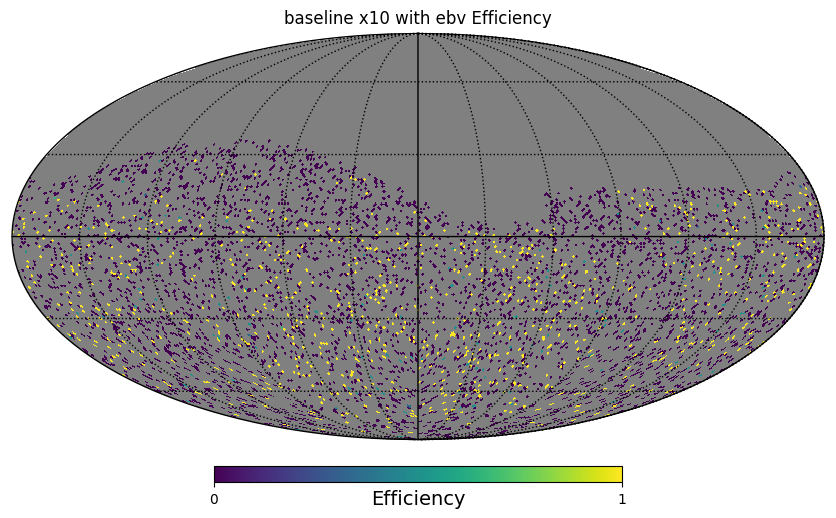

In [28]:
plot_map(big_baseline_w_ebv, title='baseline x10 with ebv')

In [56]:
big_4roll_w_ebv.iloc[0]

sid                                                                          1
mjd_obs                      [64347.14632091699, 64347.12356130418, 64291.2...
mag_obs                      [27.797270769387573, 27.793542906539518, 137.2...
snr_obs                      [0.02148259165175206, 0.02169029660605208, 6.3...
filter                       ['y', 'y', 'z', 'y', 'z', 'y', 'i', 'r', 'u', ...
first_det_mjd                                                     64327.124736
last_det_mjd                                                      64327.128764
fade_time_days                                                        8.291737
sid_duplicate                                                                1
file_indx                                                                  738
ra                                                                    0.613592
dec                                                                  -0.584861
distance_Mpc                                        

In [120]:
canon_4roll_w_ebv

,sid,mjd_obs,mag_obs,snr_obs,filter,first_det_mjd,last_det_mjd,fade_time_days,sid_duplicate,file_indx,...,detected,theta_obs,distance_modulus,year,n_observations_detected,n_filters_detected,peak_abs_mag_g,alpha_fade_g,t_jetbreak_g,peak_apparent_mag_g_noebv
0,1,"[64347.14632091699, 64347.12356130418, 64291.2...","[135.62834534877078, 135.62834534877078, 135.6...","[1.58364138132974e-45, 1.5934722839019493e-45,...","['y', 'y', 'z', 'y', 'z', 'y', 'i', 'r', 'u', ...",62336.368048,62336.398781,6.683637,1,573,...,False,0.689389,36.600676,4,4,2,-20.970405,-17.478589,-2.030252,15.630270
1,2,"[61728.131224077966, 62454.3016272885, 62454.2...","[139.0687848545479, 138.96042117114297, 138.96...","[1.0828014323656491e-45, 1.4072207627205854e-4...","['g', 'y', 'y', 'z', 'r', 'z', 'y', 'y', 'r', ...",NaN,NaN,NaN,2,420,...,False,1.348682,39.900193,3,0,0,-31.282974,-24.179292,-9.315617,8.617219
2,3,"[63420.19647675333, 61884.385486063686, 61884....","[139.5933822715131, 139.74320257787966, 139.96...","[1.1413476992946542e-46, 3.180897938078619e-46...","['i', 'r', 'g', 'r', 'i', 'r', 'g', 'r', 'z', ...",NaN,NaN,NaN,3,497,...,False,1.095423,40.118353,8,0,0,-21.067329,-11.811747,1.132810,19.051024
3,4,"[61461.32059103347, 61479.347512385575, 63769....","[136.5720611447591, 136.614945962686, 136.5807...","[3.176035669091092e-46, 7.066534693796446e-45,...","['y', 'r', 'z', 'i', 'r', 'y', 'i', 'u', 'z', ...",64390.339854,64403.384082,26.441860,4,832,...,True,0.147933,37.531821,10,11,5,-24.611910,-18.060369,-5.241687,12.919912
4,5,"[61490.332320421156, 61490.30894890274, 63301....","[139.41414682816946, 139.41414682816946, 139.5...","[4.655227969988259e-47, 6.892685700689584e-47,...","['y', 'y', 'r', 'i', 'g', 'z', 'r', 'i', 'r', ...",62820.347912,62820.357274,20.908079,5,580,...,False,1.532504,40.271946,5,4,1,-28.636955,-23.420527,-6.617520,11.634991
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
532,770,"[61152.36380929522, 62275.28650163447, 61510.2...","[137.5678012092145, 137.26666319681965, 136.82...","[2.172905160189251e-45, 2.8128904077668726e-45...","['g', 'r', 'y', 'g', 'z', 'r', 'z', 'z', 'z', ...",NaN,NaN,NaN,770,827,...,False,0.379566,37.418576,5,0,0,-28.779542,-23.866882,-9.078292,8.639034
533,771,"[61052.308222237596, 61159.14825010393, 62626....","[139.26969745046603, 139.04830521936515, 139.5...","[3.4920531218963254e-46, 5.297167001338137e-47...","['r', 'y', 'u', 'i', 'g', 'r', 'y', 'u', 'r', ...",NaN,NaN,NaN,771,139,...,False,0.894116,39.840568,1,0,0,-21.664030,-15.145170,-2.616712,18.176538
534,773,"[61494.0823030973, 61494.059048552605, 62235.0...","[140.54037282999283, 139.52883087825083, 139.5...","[2.4238303949252894e-46, 5.321751054004822e-46...","['g', 'r', 'r', 'i', 'i', 'g', 'i', 'i', 'y', ...",NaN,NaN,NaN,773,860,...,False,1.334290,37.680050,10,0,0,-31.521384,-23.241017,-6.828207,6.158665
535,774,"[64207.329832043004, 63525.276069746185, 63184...","[135.17252201953306, 135.17872462675373, 135.1...","[8.14761717254589e-45, 8.496022416910503e-45, ...","['i', 'r', 'u', 'r', 'r', 'i', 'z', 'i', 'i', ...",NaN,NaN,NaN,774,961,...,False,0.007448,36.152856,3,0,0,-27.542240,-19.954115,-4.515810,8.610616


In [150]:
mjd0 = 60980.5

In [177]:
time_gap_detected = []
time_gap_not_detected = []
for i, row in canon_4roll_w_ebv.iterrows():
    time_gap = np.array(ast.literal_eval(row['mjd_obs']))-(row['peak_time'] + mjd0)
    # print(time_gap)
    if len(time_gap[time_gap>0])<1:
        continue
    smallest_g_0 = np.min(time_gap[time_gap>0])
    if row['detected']==True:
        time_gap_detected.append(smallest_g_0)
    else:
        time_gap_not_detected.append(smallest_g_0)

In [159]:
len(time_gap_not_detected)

435

Text(0.5, 0, 'Time gap')

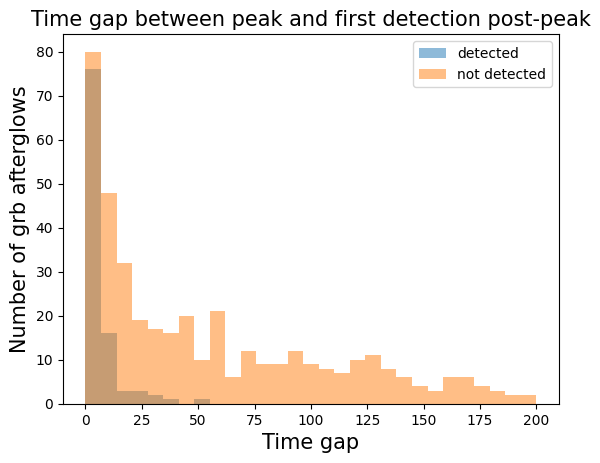

In [183]:
plt.hist(time_gap_detected,bins=np.linspace(0,200,30),alpha=.5,label="detected")
plt.hist(time_gap_not_detected,bins=np.linspace(0,200,30),alpha=.5,label="not detected")
plt.title("Time gap between peak and first detection post-peak",size=15)
plt.legend()
plt.ylabel("Number of grb afterglows", size=15)
plt.xlabel("Time gap",size=15)

In [163]:
df_obs = canon_4roll_w_ebv

(40.0, -5.0)

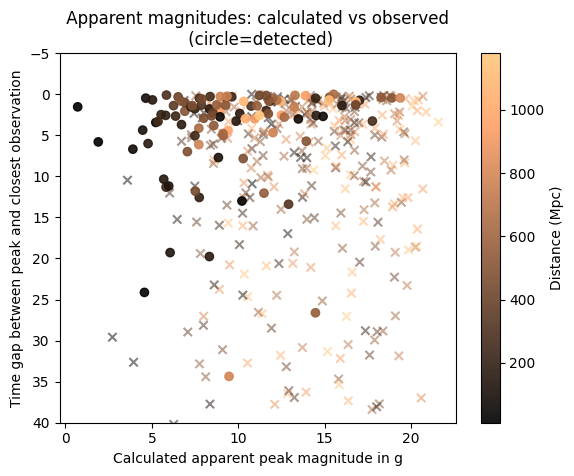

In [171]:
fig, ax = plt.subplots()
not_detected_df = df_obs[df_obs['detected']==False]
detected_df = df_obs[df_obs['detected']==True]
plt.scatter(not_detected_df['peak_apparent_mag_g_noebv'], time_gap_not_detected, marker='x',c=not_detected_df['distance_Mpc'], alpha=.5, cmap='copper')
plt.scatter(detected_df['peak_apparent_mag_g_noebv'], time_gap_detected, marker='o',c=detected_df['distance_Mpc'], alpha=.9, cmap='copper')
plt.title(" Apparent magnitudes: calculated vs observed \n (circle=detected)")
plt.xlabel("Calculated apparent peak magnitude in g")
plt.ylabel("Time gap between peak and closest observation")
ax.yaxis.set_inverted(True)
plt.colorbar(label="Distance (Mpc)")
plt.ylim(40,-5)

In [ ]:
plt.scatter(time_gap

In [146]:
np.sum(canon_4roll_w_ebv['peak_apparent_mag_g_noebv']<24)

np.float64(26360.18487971366)

In [147]:
np.sum(canon_4roll_w_ebv['peak_mag_observed']<28)

np.int64(295)

In [145]:
len(canon_4roll_w_ebv)

537

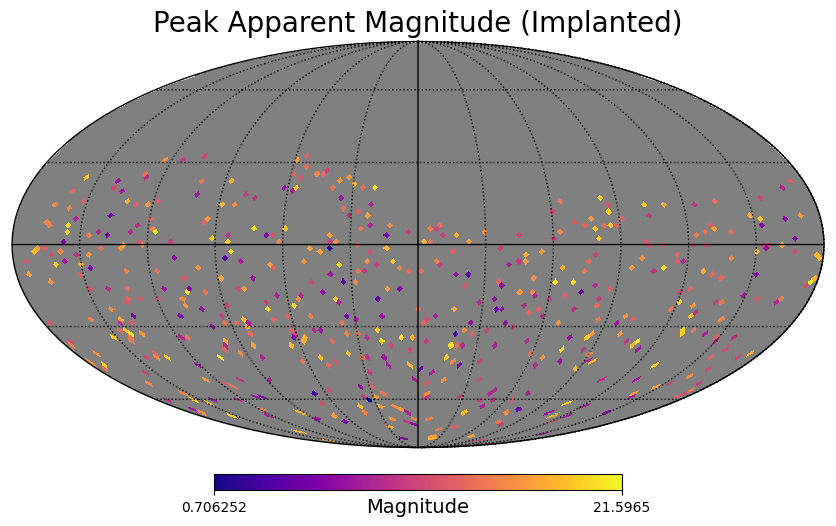

In [137]:
plot_magnitude_map(canon_4roll_w_ebv)

In [136]:
def plot_magnitude_map(df, title=None):
    '''
    takes obs_record dataframe, plots map colored by peak apparent magnitude
    '''
    nside = 32
    npix = hp.nside2npix(nside)
    
    # Initialize map with UNSEEN values
    mag_map = np.full(npix, hp.UNSEEN)
    
    # Convert coordinates
    ra_rad = df['ra']
    dec_rad = df['dec']
    theta = 0.5 * np.pi - dec_rad
    phi = ra_rad
    pix_inds = hp.ang2pix(nside, theta, phi)
    
    # Get magnitude values
    mag_values = df['peak_apparent_mag_g_noebv'].values
    
    # For each pixel, calculate statistics of observations in that pixel
    pixel_mags = {}
    for i, pix in enumerate(pix_inds):
        if pix not in pixel_mags:
            pixel_mags[pix] = []
        pixel_mags[pix].append(mag_values[i])
    
    # Set pixel values (you can choose mean, median, min, max, etc.)
    for pix, mags in pixel_mags.items():
        mag_map[pix] = np.mean(mags)  # or np.median(mags), np.min(mags), etc.
    
    # Plot the map
    hp.mollview(mag_map,
               unit='Magnitude', cmap='plasma')
    plt.title(f"Peak Apparent Magnitude (Implanted)", fontsize=20)
    hp.graticule()
    plt.show()

In [141]:
for i, row in df_obs.iterrows():
    mjd = np.array(ast.literal_eval(row['mjd_obs']))
    print(len(mjd))
    print(np.max(mjd))
    if i>15:
        break


754
64620.35621902449
773
64625.2350072792
204
64585.028694388144
771
64567.03879163285
828
64522.05118592857
756
64596.39496864886
789
64483.15399831569
694
64606.102420462936
743
64612.09522076328
826
64611.99898975245
784
64433.02400957812
765
64483.0534905829
802
64629.11057064911
800
64611.00553031167
204
64626.0672536323
815
64475.189019941754
566
64578.99182140188


In [185]:
not_detected_df = df_obs[df_obs['detected']==False]
detected_df = df_obs[df_obs['detected']==True]

Text(0.5, 0, 'Peak Apparent Mag as injected')

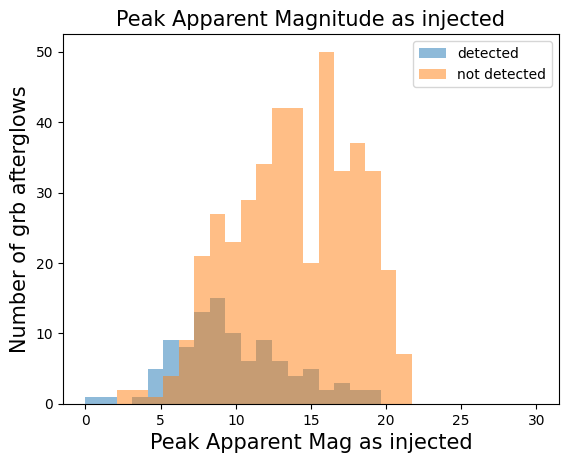

In [188]:
plt.hist(detected_df['peak_apparent_mag_g_noebv'],bins=np.linspace(0,30,30),alpha=.5,label="detected")
plt.hist(not_detected_df['peak_apparent_mag_g_noebv'],bins=np.linspace(0,30,30),alpha=.5,label="not detected")
plt.title("Peak Apparent Magnitude as injected",size=15)
plt.legend()
plt.ylabel("Number of grb afterglows", size=15)
plt.xlabel("Peak Apparent Mag as injected",size=15)

(40.0, 5.0)

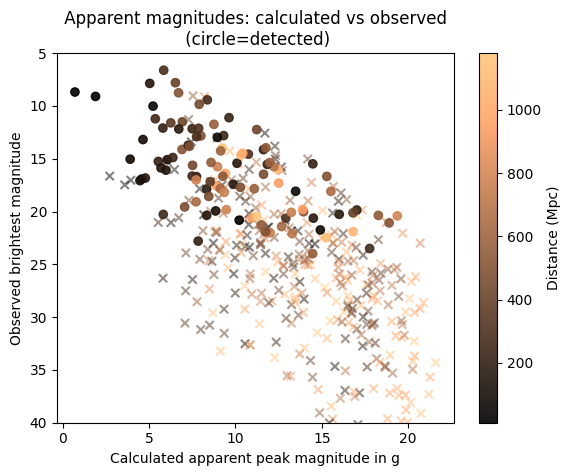

In [184]:
fig, ax = plt.subplots()

plt.scatter(not_detected_df['peak_apparent_mag_g_noebv'], not_detected_df['peak_mag_observed'], marker='x',c=not_detected_df['distance_Mpc'], alpha=.5, cmap='copper')
plt.scatter(detected_df['peak_apparent_mag_g_noebv'], detected_df['peak_mag_observed'], marker='o',c=detected_df['distance_Mpc'], alpha=.9, cmap='copper')
plt.title(" Apparent magnitudes: calculated vs observed \n (circle=detected)")
plt.xlabel("Calculated apparent peak magnitude in g")
plt.ylabel("Observed brightest magnitude")
ax.yaxis.set_inverted(True)
plt.colorbar(label="Distance (Mpc)")
plt.ylim(40,5)

In [4]:
df_kcor = pd.read_csv('/lustre/lrspec/metrics/results/GRBafterglows/GRBafterglows_den_1e-07_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_False_kcor_True_None_None_obs_recordObsRecords_baseline_v4.3.1_10yrs.csv')

In [7]:
df_no_kcor = pd.read_csv('/lustre/lrspec/metrics/results/GRBafterglows/GRBafterglows_den_1e-07_d_None-None_Mpc_z_0.00226-0.3_Mpc_ext_False_None_None_obs_recordObsRecords_baseline_v4.3.1_10yrs.csv')

(40.0, 5.0)

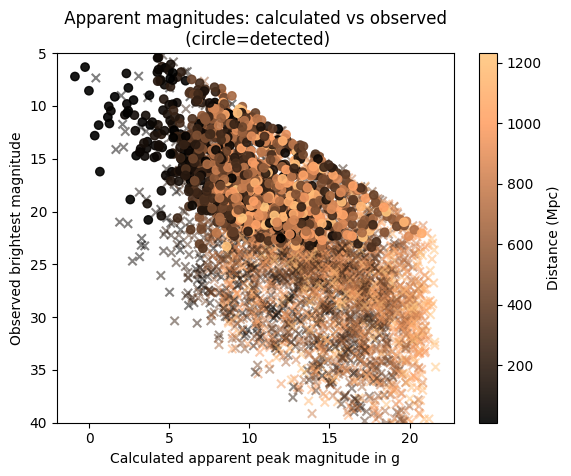

In [6]:
fig, ax = plt.subplots()
detected_df = df_kcor[df_kcor['detected']==True]
not_detected_df = df_kcor[df_kcor['detected']==False]

plt.scatter(not_detected_df['peak_apparent_mag_g_noebv'], not_detected_df['peak_mag_observed'], marker='x',c=not_detected_df['distance_Mpc'], alpha=.5, cmap='copper')
plt.scatter(detected_df['peak_apparent_mag_g_noebv'], detected_df['peak_mag_observed'], marker='o',c=detected_df['distance_Mpc'], alpha=.9, cmap='copper')
plt.title(" Apparent magnitudes: calculated vs observed \n (circle=detected)")
plt.xlabel("Calculated apparent peak magnitude in g")
plt.ylabel("Observed brightest magnitude")
ax.yaxis.set_inverted(True)
plt.colorbar(label="Distance (Mpc)")
plt.ylim(40,5)

KeyError: 'peak_apparent_mag_g_noebv'

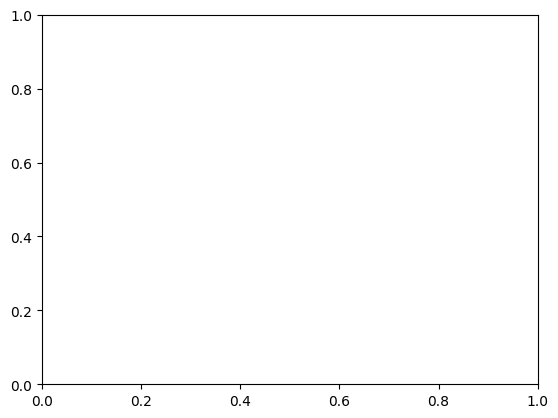

In [8]:
fig, ax = plt.subplots()
detected_df = df_no_kcor[df_no_kcor['detected']==True]
not_detected_df = df_no_kcor[df_no_kcor['detected']==False]

plt.scatter(not_detected_df['peak_apparent_mag_g_noebv'], not_detected_df['peak_mag_observed'], marker='x',c=not_detected_df['distance_Mpc'], alpha=.5, cmap='copper')
plt.scatter(detected_df['peak_apparent_mag_g_noebv'], detected_df['peak_mag_observed'], marker='o',c=detected_df['distance_Mpc'], alpha=.9, cmap='copper')
plt.title(" Apparent magnitudes: calculated vs observed \n (circle=detected)")
plt.xlabel("Calculated apparent peak magnitude in g")
plt.ylabel("Observed brightest magnitude")
ax.yaxis.set_inverted(True)
plt.colorbar(label="Distance (Mpc)")
plt.ylim(40,5)

In [5]:
obs_record = pd.read_csv('/lustre/lrspec/metrics/results/GRBafterglows/GRBafterglows_den_1e-09_d_None-None_Mpc_z_0.00226-4.5_Mpc_ext_True_kcor_True_None_None_obs_recordObsRecords_four_roll_v5.0.0_10yrs.csv')

[33.367910180808146 27.635686539833053 28.016341333980982
 32.37791688634809 32.373211872509096 33.969020220864856
 28.392069159417794]
[0.00040103 0.1481093  0.20534188 0.00036142 0.00034848 0.00032646
 0.102966  ]
[[0.09019608 0.74509804 0.81176471 1.        ]
 [0.89019608 0.46666667 0.76078431 1.        ]
 [0.58039216 0.40392157 0.74117647 1.        ]
 [0.7372549  0.74117647 0.13333333 1.        ]
 [0.7372549  0.74117647 0.13333333 1.        ]
 [0.09019608 0.74509804 0.81176471 1.        ]
 [0.17254902 0.62745098 0.17254902 1.        ]]
[False False False False False False False]
<class 'numpy.bool'>
<class 'numpy.bool'>
<class 'numpy.bool'>
<class 'numpy.bool'>
<class 'numpy.bool'>
<class 'numpy.bool'>
<class 'numpy.bool'>
True
<class 'bool'>
False
<class 'bool'>


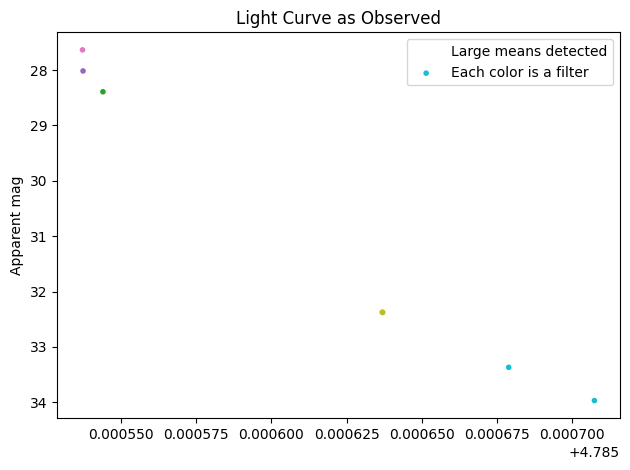

In [56]:
plot_observed_light_curve(obs_record.iloc[0],log="fake",ylim=False)

In [44]:
mags = np.array(ast.literal_eval(obs_record.iloc[0]['mag_obs'].replace('nan', 'None')))
# mags = np.array(ast.literal_eval(row['mag_obs'].replace('nan', 'None')))


In [45]:
mags

array([None, None, None, None, None, None, None, None, None, None, None,
       None, None, None, None, None, None, None, None, None,
       33.367910180808146, None, None, None, None, None, None, None, None,
       None, None, None, None, None, None, None, None, None, None, None,
       None, None, None, None, None, None, None, None, None, None, None,
       None, None, None, None, None, None, None, None, None, None, None,
       None, None, None, None, None, None, None, None, None, None, None,
       None, None, None, None, None, None, None, None, None, None, None,
       None, None, None, None, None, None, None, None, None, None, None,
       None, None, None, None, None, None, None, None, None, None, None,
       None, None, None, None, None, None, None, None, None, None, None,
       None, None, None, None, None, None, None, None, None, None, None,
       None, None, None, None, None, None, None, None, None, None, None,
       None, None, None, None, None, None, None, None, None, 

In [48]:
obs_record.iloc[0]['filter']

"['r', 'g', 'i', 'y', 'r', 'g', 'y', 'r', 'g', 'r', 'y', 'i', 'u', 'r', 'y', 'y', 'z', 'i', 'r', 'y', 'z', 'i', 'r', 'z', 'g', 'i', 'r', 'r', 'y', 'z', 'y', 'y', 'i', 'z', 'z', 'i', 'z', 'z', 'y', 'r', 'i', 'y', 'i', 'i', 'z', 'y', 'r', 'r', 'u', 'z', 'g', 'z', 'i', 'g', 'u', 'y', 'r', 'z', 'i', 'y', 'i', 'z', 'i', 'r', 'i', 'u', 'g', 'g', 'y', 'g', 'z', 'g', 'i', 'u', 'y', 'y', 'g', 'z', 'r', 'y', 'r', 'u', 'z', 'i', 'g', 'y', 'i', 'r', 'r', 'g', 'u', 'u', 'r', 'i', 'u', 'i', 'r', 'i', 'z', 'y', 'i', 'z', 'r', 'z', 'r', 'i', 'r', 'r', 'r', 'y', 'y', 'u', 'u', 'i', 'z', 'r', 'g', 'u', 'r', 'r', 'r', 'r', 'y', 'z', 'y', 'z', 'i', 'r', 'u', 'y', 'g', 'r', 'z', 'i', 'r', 'i', 'z', 'y', 'y', 'i', 'g', 'i', 'g', 'u', 'z', 'r', 'r', 'y', 'i', 'r', 'r', 'u', 'i', 'z', 'y', 'z', 'z', 'z', 'i', 'z', 'r', 'y', 'i', 'y', 'r', 'g', 'y', 'z', 'i', 'z', 'r', 'i', 'r', 'z', 'i', 'r', 'y', 'u', 'y', 'g', 'u', 'i', 'i', 'y', 'z', 'y', 'i', 'r', 'z', 'i', 'r', 'y', 'y', 'u', 'r', 'i', 'g', 'y', 'y', 'y'